# Ouroboros with Scanpy

Welcome to our tutorial on how to use Ouroboros with Scanpy. This tutorial will cover how to run Ouroboros and visualize the results within a Scanpy workflow. For more information on the Scanpy steps see their workflow: [https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html] or single cell best practices: [https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html]

Assuming you have Ouroboros already installed, start by import your packages. 

In [1]:
import scanpy as sc
import anndata as ad
import numpy as np
import ouroboros as obo
import importlib_resources as resources
import seaborn as sns
import pandas as pd

We have included a test dataset which is a subset of cells from a neurogenesis dataset published by Paun et al. [https://pubmed.ncbi.nlm.nih.gov/36931659/] which you can read in like so to test your ouroboros installation 

## Filtering

In [12]:
# Read in test dataset - subsetted to existing features
with resources.path("ouroboros.data", "neurogen_example.h5ad") as path:
    adata = sc.read_h5ad(path)
    
adata

AnnData object with n_obs × n_vars = 400 × 60649
    obs: 'cell_type'

We have provided the check_genes() to test if your annadata object is missing any of the Ouroboros feature genes. If any genes are missing and you run Ouroboros, the VAE will be retrained using only the feature genes present in your matrix. This may result in lower accuracy. To ensure the model is as accurate as possible, avoid filtering out any feature genes. 

Example usage: 
```
check_genes(
    data: anndata.AnnData
) -> list[str]
```

Returns a list of Ouroboros feature genes missing from your anndata. 

In [3]:
# See if any genes are missing from the annadata 
missing_genes = obo.check_genes(adata)

No feature genes are missing from your anndata


Next you can calculate your QC metrics like you normally would in Scanpy.

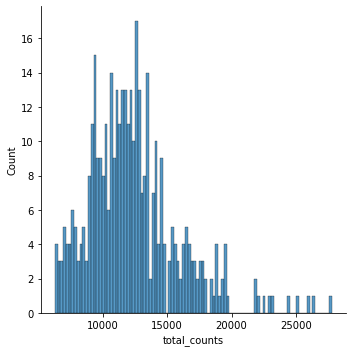

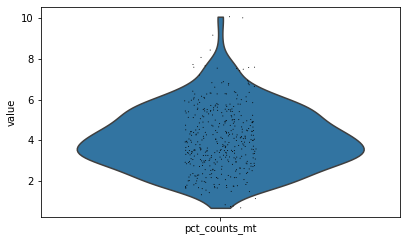

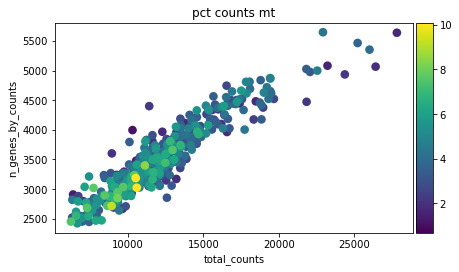

In [4]:
# Continue with nomal scanpy filtering

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

# Calculate QC metrics with scanpy 
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)

# Plot QC metrics
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

After calculating QC metrics you can then set your filtering thresholds. For more information on this see single cell best practices [https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html]

In [5]:
sc.pp.filter_cells(adata, min_genes=20)
# Usually you would use Scanpy to filter genes with sc.pp.filter_genes(), but if any of our feature genes have low counts they will be removed and then the model will retrain
# If you want Ouroboros to be as accurate as possible, it's best to leave all feature genes in the matrix, even if they have low counts 

# Alternative way to filter genes to keep feature genes present:
# Read in feature genes
feature_genes = obo.read_in_features()
# Count how many cells each gene is expressed in
gene_counts = np.array((adata.X > 0).sum(axis=0)).flatten()
# Apply min_cells threshold
gene_mask = gene_counts >= 3
# Get gene names
gene_names = adata.var_names.to_numpy()
# Force-keep genes in keep_genes
gene_mask |= np.isin(gene_names, list(feature_genes))
# Subset the AnnData
adata = adata[:, gene_mask].copy()
adata

AnnData object with n_obs × n_vars = 400 × 16256
    obs: 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

## Run Ouroboros

Great now our object is ready to run Ouroboros! 

In [6]:
# The first step is the save a copy of your filtered adata object with adata.layers['raw_counts'] - this layer is what Ouroboros will run on

# save your raw counts 
adata.layers['raw_counts'] = adata.X.copy()

# write the adata to a H5AD
adata.write_h5ad('output_example/example.h5ad')

In [7]:
# Then you can run Ouroboros on the saved h5ad 
z_df = obo.run_ouroboros('output_example/example.h5ad', 'h5ad', species = 'human', outdir = '.')


⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⢀⣠⣴⡶⢿⣟⡛⣿⢉⣿⠛⢿⣯⡈⠙⣿⣦⡀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⣠⡾⠻⣧⣬⣿⣿⣿⣿⣿⡟⠉⣠⣾⣿⠿⠿⠿⢿⣿⣦⠀⠀⠀
⠀⠀⠀⠀⣠⣾⡋⣻⣾⣿⣿⣿⠿⠟⠛⠛⠛⠀⢻⣿⡇⢀⣴⡶⡄⠈⠛⠀⠀⠀
⠀⠀⠀⣸⣿⣉⣿⣿⣿⡿⠋⠀⠀⠀⠀⠀⠀⠀⠈⢿⣇⠈⢿⣤⡿⣦⠀⠀⠀⠀
⠀⠀⢰⣿⣉⣿⣿⣿⠏⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⠦⠀⢻⣦⠾⣆⠀⠀⠀
⠀⠀⣾⣏⣿⣿⣿⡟⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⣿⡶⢾⡀⠀⠀
⠀⠀⣿⠉⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣿⣧⣼⡇⠀⠀
⠀⠀⣿⡛⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣿⣧⣼⡇⠀⠀
⠀⠀⠸⡿⢻⣿⣿⣿⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣼⣿⣥⣽⠁⠀⠀
⠀⠀⠀⢻⡟⢙⣿⣿⣿⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣠⣾⣿⣧⣸⡏⠀⠀⠀
⠀⠀⠀⠀⠻⣿⡋⣻⣿⣿⣿⣦⣤⣀⣀⣀⣀⣀⣠⣴⣿⣿⢿⣥⣼⠟⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠈⠻⣯⣤⣿⠻⣿⣿⣿⣿⣿⣿⣿⣿⣿⠛⣷⣴⡿⠋⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠈⠙⠛⠾⣧⣼⣟⣉⣿⣉⣻⣧⡿⠟⠋⠁⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀Sphere visualization complete⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀


Alternatively you can run this on the command line:

```bash
conda activate ouroboros_env
```

```bash 
ouroboros \
    --data example.h5ad  \
    --data_type h5ad \
    --species human \
    --outdir output_example
```

And then just read in z_df from the output directory
```python
z_df = pd.read_csv('ouroboros_embeddings_pseudotimes.csv')
```


z_df contains:
**dim1, dim2, dim3:** 3D spherical coordinates representing the position of each cell in VAE latent space
**KNN_phase:** Discrete phase predictions output by Ouroboros based on KNN of each cell to the reference dataset in VAE latent space 
**cell_cycle_pseudotime:** Continuous cell cycle pseudotime values. Ranges from 0 - 1. 
**dormancy_depth:** Continuous dormancy depth values. Ranges from 0 to -1. In our manuscript cells with dormancy depth < -0.6 appeared to more senescent-like, where cells with > -0.6 appeared more quiescent-like. 



### Plotting Ouroboros sphere

Plots of KNN phase, dormancy depth and cell cycle pseudotime are included in the ouroboros output folder, but if you want to make your own plots you can do so with our function plot_sphere()

```python
plot_sphere(
    z_df: pd.DataFrame,
    colour_by: str = 'KNN_phase',
    palette: dict | str = None,
    ref: pd.DataFrame = None,
    velocity: pd.DataFrame = None,
    marker_size: int = 2,
    cycle_pole: list[float] = reference_CC_pole_point,
    savefig: str = None,
    show: bool = False
)
```



| Parameter     | Type            | Description                                                                                                                                                         |
| ------------- | --------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `z_df`        | `DataFrame`     | The main cell dataframe with 3D spherical coordinates (`dim1`, `dim2`, `dim3`) and metadata columns such as phase labels or pseudotime.                             |
| `colour_by`   | `str`           | Column in `z_df` to color points by (e.g. `'KNN_phase'`, `'cell_cycle_pseudotime'`, `'dormancy_depth'`).                                                            |
| `palette`     | `dict` or `str` | Optional color map: dictionary for categorical data (e.g {`'G1'`: `'blue'`, `'G2M'`: `'green'`}), or colormap name (e.g. `'mako'`, `'rocket_r'`) for continuous data. If `None`, an appropriate default is used. |
| `ref`         | `DataFrame`     | Optional reference dataset to overlay, with columns `dim1`, `dim2`, `dim3`, and `phase`.                                                                            |
| `velocity`    | `DataFrame`     | Optional velocity vectors with columns `dim1`, `dim2`, `dim3`.                                                                                                      |
| `marker_size` | `int`           | Size of scatter points.                                                                                                                                             |
| `cycle_pole`  | `list[float]`   | A 3D point marking the known cell cycle pole for axis. If you did not retrain model, the reference is correct and you do not need to supply it. If you did retrain the model, you can either provide 'None' and not plot it, or use find_cycle_pole to identify it                                                                                                  |
| `savefig`     | `str`           | If provided, saves the plot as an HTML file to this path.                                                                                                           |
| `show`        | `bool`          | Whether to display the figure in a browser (via `plotly`).                                                                                                          |




If you retrained the VAE because you had missing genes, your cycle_pole will be in a different spot - run find_cycle_pole() to find it's coordinates and supply this to the plotting function if you want the north-south pole to be drawn on the plot. Otherwise provide 'None'

Example usage: 
```python
find_cycle_pole(    
    ref_embed: pd.DataFrame = None,
)
```

| Parameter     | Type            | Description                                                                                                                                                         |
| ------------- | --------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `ref_embed`         | `DataFrame`     | Reference dataset embeddings, with columns `dim1`, `dim2`, `dim3`, and `phase`.                                                                            |



In [ ]:
# We did not need to retrain the VAE in this tutorial, so to include reference embedding points we can just read in Ouroboros's saved points:
ref_embed = obo.read_in_refembed()

# and run plot_sphere()
obo.plot_sphere(z_df, colour_by = 'KNN_phase', ref = ref_embed, show = True)

# Note - output of plot_sphere not shown here because it is too big to render
# To view an example of the sphere output, download output_example/*.html and load it in your browser

In [ ]:
# If you did retrain the VAE you could instead run: 
ref_embed = pd.read_csv('output_example/reference_embeddings.csv')

# You may then also want to find the retrained cycle pole
cycle_pole = obo.find_cycle_pole(ref_embed)

# Plot the retrained VAE latent space with updated reference embedding points and cycle pole
obo.plot_sphere(z_df, colour_by = 'KNN_phase', ref = ref_embed, show = False, cycle_pole = cycle_pole)


You can plot variables that are in adata but not in z_df by adding them to z_df with their index:

In [ ]:
cell_type = adata.obs[['cell_type']]

z_df = z_df.merge(cell_type, how = 'left', left_index = True, right_index = True)

obo.plot_sphere(z_df, colour_by = 'cell_type', ref = ref_embed, show = True)

# Note - output of plot_sphere not shown here because it is too big to render
# To view an example of the sphere output, download output_example/*.html and load it in your browser

We have also created a function to plot the expression of a gene from the adata on the sphere:

Example usage: 
```python
plot_gene_sphere(
    z_df: pd.DataFrame,
    adata: anndata.AnnData,
    gene_name: str,
    layer: str = None,
    ref: pd.DataFrame = None,
    ref_color: str = 'putative_phase_transition',
    ref_pal: dict = phase_pal_transition,
    velocity: pd.DataFrame = None,
    show: bool = False,
    outpath: str = None,
    cycle_pole: list[float] = reference_CC_pole_point
)
```

| Parameter    | Type                    | Description                                                                                   |
| ------------ | ----------------------- | --------------------------------------------------------------------------------------------- |
| `z_df`       | `DataFrame`             | DataFrame containing embedded cell coordinates (`dim1`, `dim2`, `dim3`) and metadata columns. |
| `adata`      | `AnnData`               | The original single-cell data object containing expression values.                            |
| `gene_name`  | `str`                   | Gene to plot. Must exist in `adata.var_names`.                                                |
| `layer`      | `str`, optional         | Name of the `.layers` slot in `adata` to use (e.g. `"log_counts"`). Defaults to `.X`.         |
| `ref`        | `DataFrame`, optional   | Optional reference cells with `dim1`, `dim2`, `dim3`, and metadata like phase.                |
| `velocity`   | `DataFrame`, optional   | Optional velocity vectors (same shape as `z_df`) with `dim1`, `dim2`, `dim3`.  See plot_velocity for more information.               |
| `show`       | `bool`, default `False` | Whether to display the plot interactively in a Jupyter notebook.                                                    |
| `outpath`    | `str`, optional         | If provided, saves the interactive Plotly figure as HTML.                                     |
| `cycle_pole` | `list[float]`           |  A 3D point marking the known cell cycle pole for axis. If you did not retrain model, the reference is correct and you do not need to supply it. If you did retrain the model, you can either provide 'None' and not plot it, or use find_cycle_pole to identify                                    |


In [ ]:
obo.plot_gene_sphere(z_df, adata, gene_name = 'TP53', ref = ref_embed, show = True)

# Note - output of plot_sphere not shown here because it is too big to render
# To view an example of the sphere output, download output_example/*.html and load it in your browser

In [ ]:
import plotly.graph_objects as go


Finally we have included a function to take a still snapshot of the sphere and output a png. For this the user provides latitude and longitude values that specify where on the sphere the camera will be looking. I found it easiest to set the north-south axis to be the cell cycle pole drawn through the sphere, and rotate all the points such that the sphere is oriented to north-south. Doing this will ensure that the latitude and longtiude provided will rotate the sphere in a similar way to a globe of the earth. We have provided a function do so: 

```python
rotate_north(
    z_df: pd.DataFrame,
    reference_CC_pole_point: list[float] = [0.86202236, 0.24824865, 0.44191636]
) 
```

| Parameter                 | Type                    | Description                                                                                        |
| ------------------------- | ----------------------- | -------------------------------------------------------------------------------------------------- |
| `z_df`                    | `DataFrame`             | Input dataframe containing spherical coordinates (`dim1`, `dim2`, `dim3`) for each cell.           |
| `reference_CC_pole_point` | `list[float]`, optional | 3D vector indicating the "pole" direction to rotate. Default is the original Ouroboros cycle pole. |



This function returns: 

| Type        | Description                                                                                         |
| ----------- | --------------------------------------------------------------------------------------------------- |
| `DataFrame` | A copy of `z_df` with rotated `dim1`, `dim2`, `dim3` values so that the pole points to `[0, 0, 0]`. |


After rotating, you can call the sphere_snapshot() function to produce a png of the sphere at a given latitude and longtiude: 

Example usage: 
```python
sphere_snapshot(
    lat: int,
    long: int, 
    z_df: pd.DataFrame,
    colour_by: str, 
    radius: float, 
    gene_name: str,
    layer: str = None,
    ref_embed: pd.DataFrame = None,
    vel_df: pd.DataFrame = None,
    save_as_png: str # ex. /path/to/output/png
    cycle_pole: list[float] = [0,0,1]
)
```
| Parameter     | Type                      | Description                                                                                                                               |
| ------------- | ------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------- |
| `lat`         | `int`                     | Latitude angle (in degrees) to position the camera viewpoint. Must be in `[-90, 90]`.                                                     |
| `lon`         | `int`                     | Longitude angle (in degrees) to position the camera viewpoint. Must be in `[0, 360]`.                                                     |
| `z_df`        | `DataFrame`               | DataFrame containing spherical embedding coordinates (`dim1`, `dim2`, `dim3`) and metadata.                                               |
| `colour_by`   | `str`                     | Column in `z_df` to color points by (e.g., `'KNN_phase'`, `'cell_cycle_pseudotime'`).                                                     |
| `radius`      | `float`, optional         | Distance from the sphere center to the virtual camera. Controls zoom level.                                                               |
| `palette`     | `dict` or `str`, optional | Color palette. Use a dictionary for categorical values or a colormap name (e.g., `'mako'`) for continuous values.                         |
| `ref_embed`   | `DataFrame`, optional     | Optional reference dataset with `dim1`, `dim2`, `dim3`, and metadata columns (e.g., `phase`). Used for transparent background points.     |
| `vel_df`      | `DataFrame`, optional     | Optional velocity vectors with columns `dim1`, `dim2`, `dim3`. Drawn as arrows and cones.                                                 |
| `save_as_png` | `str`, optional           | Path to save the image as a PNG. If `None`, the image is not saved.                                                                       |
| `showlegend`  | `bool`, default `False`   | Whether to display the legend in the plot.                                                                                                |
| `cycle_pole`  | `list[float]`, optional   | 3D vector indicating the cell cycle pole. Defaults to `[0, 0, 1]`. If you haven't rotated the sphere the cycle pole will be off. |


In [ ]:
# Start by rotating all the points in the sphere so the top of the cycle pole is north (Lat: 90)
# We did not retrain VAE so no need to supply reference_CC_pole_point
z_df_rotated = obo.rotate_north(z_df)

# If you retrained VAE then call this function with the cycle_pole you found earlier
# rotate_north(z_df, reference_CC_pole_point = cycle_pole)

# If you want your ref_embed to be plotted to, you also need to rotate the ref embed
ref_embed_rotated = obo.rotate_north(ref_embed)

# Make your snapshot
obo.sphere_snapshot(0, 0, z_df = z_df_rotated, colour_by='dormancy_depth', radius = 1.5, ref_embed = ref_embed_rotated, vel_df = None, save_as_png='output_example/dormancy_depth.png')


## Continue Scanpy workflow and plot on UMAP

You can also proceed with a standard scanpy workflow, and plot KNN_phase, cell_cycle_pseudotime and dormancy_depth on a PCA or UMAP. 

In [ ]:
# First add KNN_phase, cell_cycle_pseudotime and dormancy_depth to adata.obs

adata.obs = adata.obs.merge(z_df[['KNN_phase', 'cell_cycle_pseudotime', 'dormancy_depth']], how = 'left', left_index = True, right_index = True)

### PCA

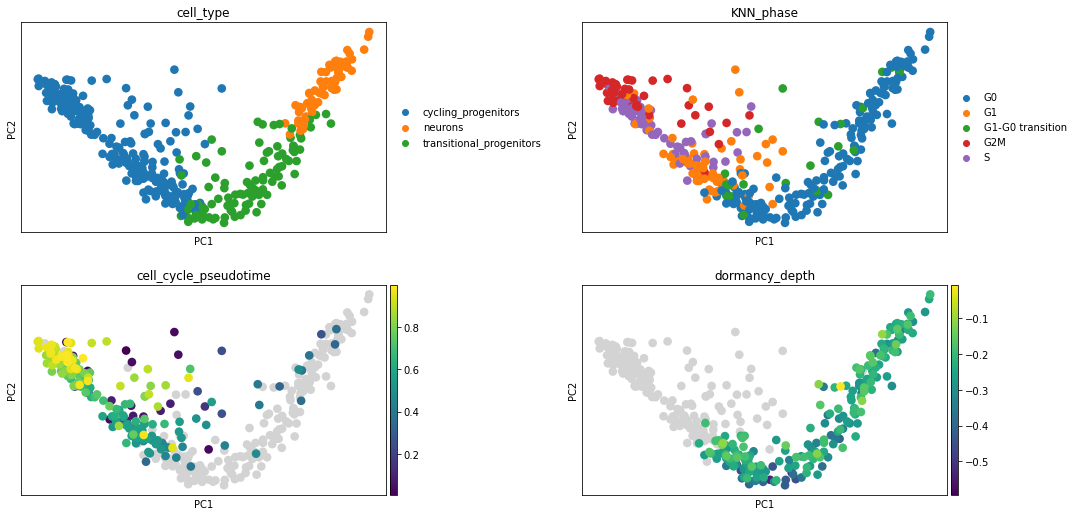

In [ ]:
# Code from Scanpy's clustering tutorial [https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html]

# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

# Feature selection
sc.pp.highly_variable_genes(adata)

#PCA
sc.tl.pca(adata)

sc.pl.pca(
    adata,
    color=["cell_type", "KNN_phase", 'cell_cycle_pseudotime', 'dormancy_depth'],
    ncols=2,
    wspace=0.4
)


### UMAP

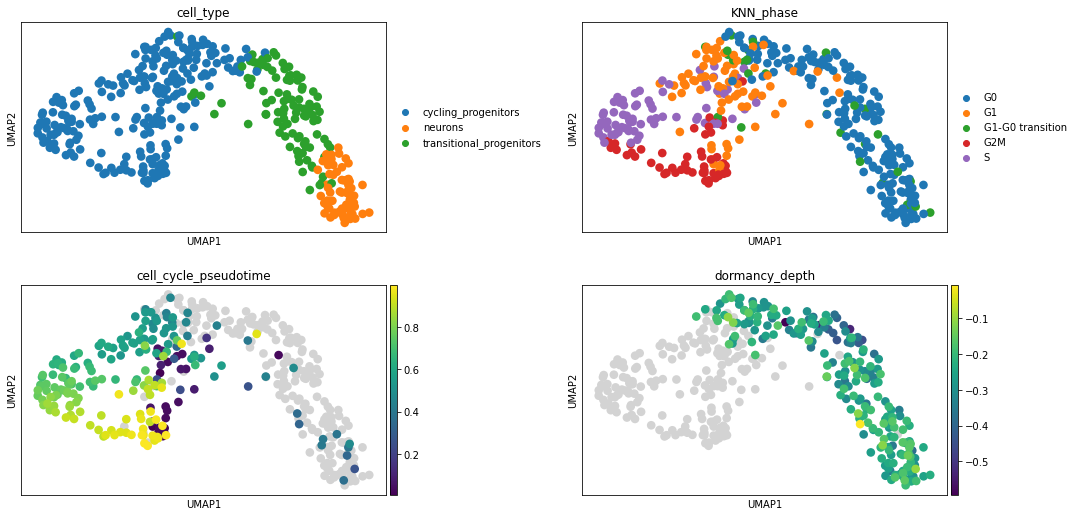

In [ ]:
# Nearest neighbour graph construction and visualization 
sc.pp.neighbors(adata)

sc.tl.umap(adata)

sc.pl.umap(
    adata,
    color=["cell_type", "KNN_phase", 'cell_cycle_pseudotime', 'dormancy_depth'],
    ncols=2,
    wspace=0.4
)

It's important to note that for many datasets the cell cycle is not the main source of variation. Because PCA and UMAP visualize the main sources of variation in a dataset, it is very possible that cells of the same phase or with similar cell cycle pseudotimes or dormancy depths may be seperated in a PCA or UMAP plot. 

## Regressing out cell cycle 

We did not thoroughly benchmark this against other methods of removing cell cycle signal, but did note that using our feature set ...
continue section...
